In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_train=pd.read_csv(r"/content/train.csv")
df_test=pd.read_csv(r"/content/test.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_train.shape

(103904, 25)

In [ ]:
df_test.shape

(25976, 25)

## Combining Training and Testing Data

In [ ]:
df = pd.concat([df_train, df_test], ignore_index=True)

print(df.shape)

(129880, 25)


In [ ]:
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
129876,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
129877,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
129878,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


## Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [ ]:
# Drop unnecessary columns
df=df.drop(['Unnamed: 0', 'id'], axis=1)

In [ ]:
# Check for missing values
df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [ ]:
# Fill missing values
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean())

In [ ]:
# check duplicate rows
df[df.duplicated()]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


In [ ]:
# Remove duplicate rows
df.drop_duplicates(keep='first',inplace=True)

## Unique Values in Each Column:

In [ ]:
unique_values = {col: df[col].unique() for col in df.columns}

In [ ]:
for col, values in unique_values.items():
    print(f"Unique values in '{col}': {values}")

Unique values in 'Gender': ['Male' 'Female']
Unique values in 'Customer Type': ['Loyal Customer' 'disloyal Customer']
Unique values in 'Age': [13 25 26 61 47 52 41 20 24 12 53 33 45 38  9 17 43 58 23 57 49 36 22 31
 15 35 67 37 40 34 39 50 29 54 21 28 27 69 60 48 59 46 30 66 64 44 51 32
 19 42 16 11 62  8 56 68 55 18 65 72 70 63 10  7 14 80 74 71 85 73 76 77
 75 79 78]
Unique values in 'Type of Travel': ['Personal Travel' 'Business travel']
Unique values in 'Class': ['Eco Plus' 'Business' 'Eco']
Unique values in 'Flight Distance': [ 460  235 1142 ... 1003 1441  884]
Unique values in 'Inflight wifi service': [3 2 4 1 5 0]
Unique values in 'Departure/Arrival time convenient': [4 2 5 3 1 0]
Unique values in 'Ease of Online booking': [3 2 5 4 1 0]
Unique values in 'Gate location': [1 3 2 5 4 0]
Unique values in 'Food and drink': [5 1 2 4 3 0]
Unique values in 'Online boarding': [3 5 2 1 4 0]
Unique values in 'Seat comfort': [5 1 2 3 4 0]
Unique values in 'Inflight entertainment': [5 1 2 3 

## Numerical Columns Analysis:

In [ ]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.407410
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
num_columns=['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']

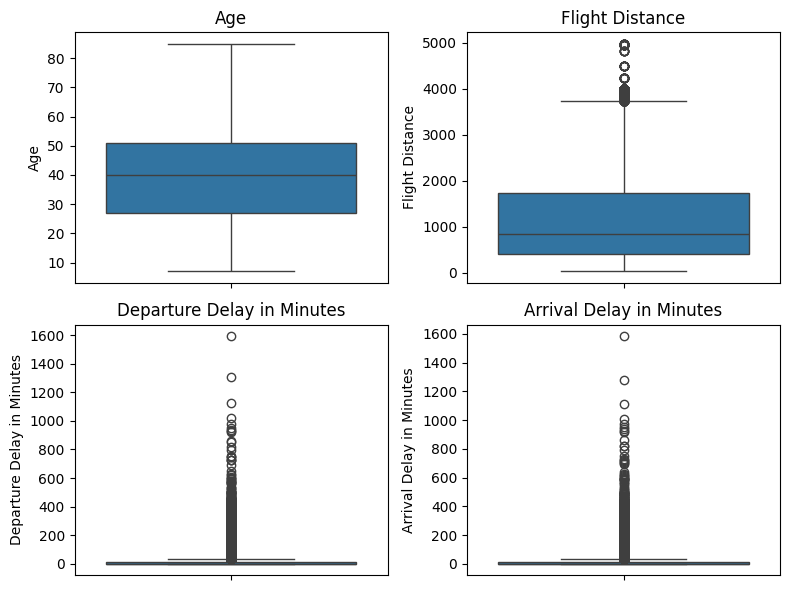

In [ ]:
num_rows=len(num_columns)//2+len(num_columns)%2
num_cols=2
fig,axes=plt.subplots(num_rows,num_cols,figsize=(8,6))
if num_rows==1:
    axes=[axes]

for i,col_name in enumerate(num_columns):
    row=i//num_cols
    col=i% num_cols
    sns.boxplot(df[col_name],ax=axes[row][col])
    axes[row][col].set_title(col_name)
plt.tight_layout()
plt.show()

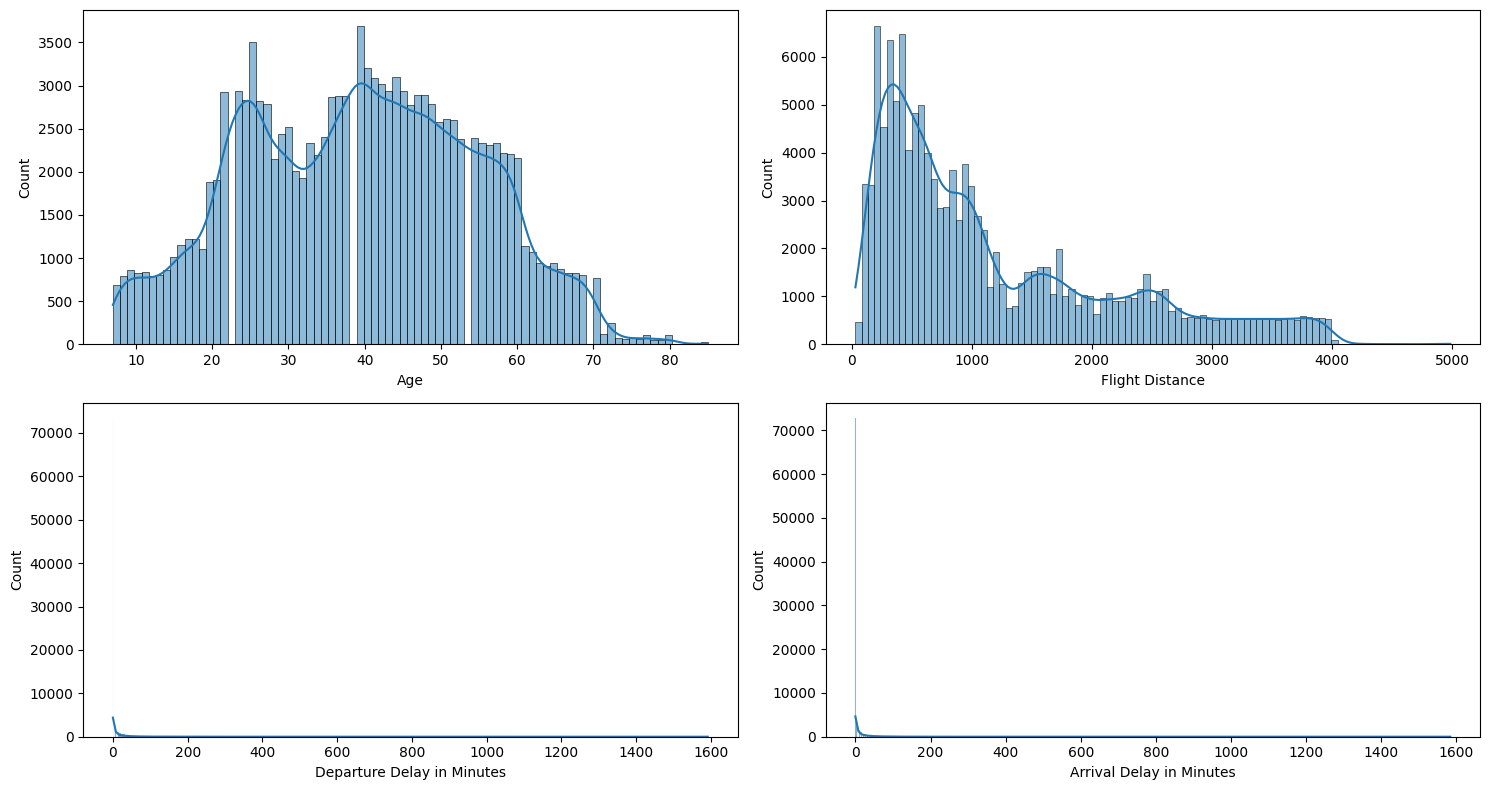

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
axs = axs.flatten()

for i, f in enumerate(num_columns):
    sns.histplot(data=df, x=f, kde=True,ax=axs[i])

plt.tight_layout()
plt.show()

## Categorical Columns Analysis:

In [ ]:
categorical_columns=['satisfaction', 'Gender', 'Type of Travel', 'Ease of Online booking', 'Class', 'Leg room service', 'Cleanliness']

<ipython-input-24-f184ba13871f>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette=palette, ax=axes[i])


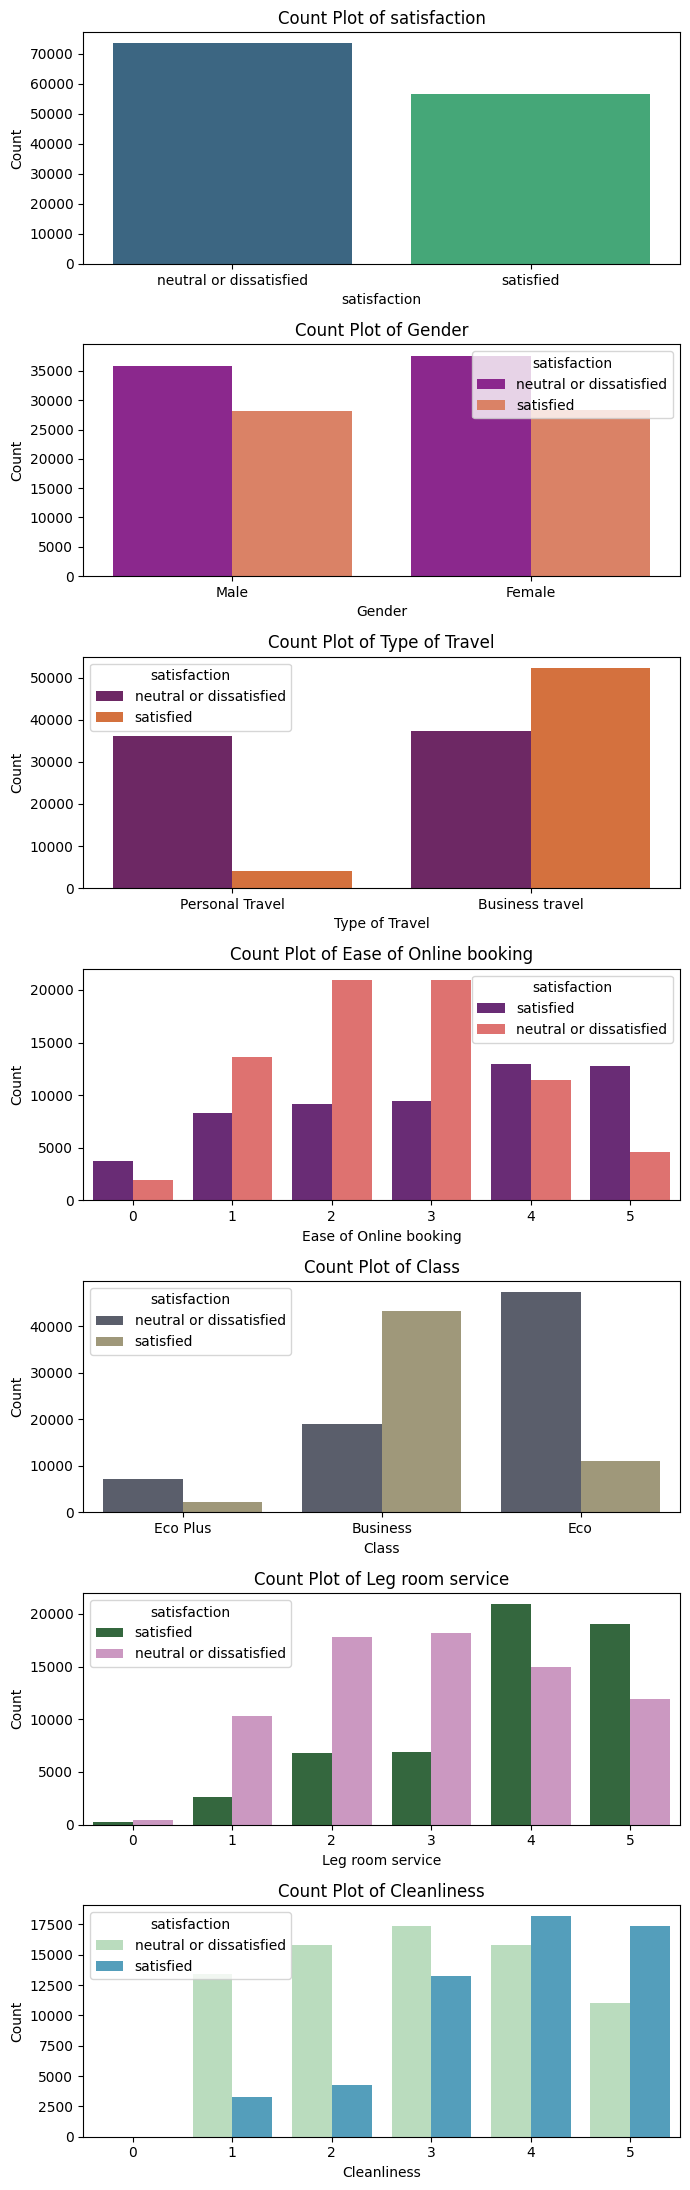

In [ ]:
color_palettes = [
    "viridis", "plasma", "inferno", "magma", "cividis",
    "cubehelix", "GnBu", "BuPu", "OrRd"
]

fig, axes = plt.subplots(len(categorical_columns), 1, figsize=(7,22))

for i, col in enumerate(categorical_columns):
    palette = color_palettes[i % len(color_palettes)]
    if col == 'satisfaction':
        sns.countplot(data=df, x=col, palette=palette, ax=axes[i])
    else:
        hue_levels = df['satisfaction'].unique()
        sns.countplot(data=df, x=col, hue='satisfaction', palette=palette, ax=axes[i])
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Count Plot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
def calculate_statistics(df, column, hue=None):
    if hue:
        stats = df.groupby([column, hue]).size().unstack(fill_value=0)
        stats['Total'] = stats.sum(axis=1)
        for hue_level in stats.columns[:-1]:  # Exclude 'Total' column from percentage calculation
            stats[f'{hue_level} %'] = (stats[hue_level] / stats['Total']) * 100
        return stats
    else:
        stats = df[column].value_counts().to_frame('Count')
        stats['Percentage %'] = (stats['Count'] / stats['Count'].sum()) * 100
        return stats

# Generate statistics for each column
for col in categorical_columns:
    print(f'Analysis of {col}')
    if col == 'satisfaction':
        stats = calculate_statistics(df, col)
    else:
        stats = calculate_statistics(df, col, hue='satisfaction')
    print(stats)
    print('\n' + '='*80 + '\n')


Analysis of satisfaction
                         Count  Percentage %
satisfaction                                
neutral or dissatisfied  73452     56.553742
satisfied                56428     43.446258


Analysis of Gender
satisfaction  neutral or dissatisfied  satisfied  Total  \
Gender                                                    
Female                          37630      28269  65899   
Male                            35822      28159  63981   

satisfaction  neutral or dissatisfied %  satisfied %  
Gender                                                
Female                        57.102536    42.897464  
Male                          55.988497    44.011503  


Analysis of Type of Travel
satisfaction     neutral or dissatisfied  satisfied  Total  \
Type of Travel                                               
Business travel                    37337      52356  89693   
Personal Travel                    36115       4072  40187   

satisfaction     neutral or dissatisfie

## Correlation Matrix Analysis:

In [ ]:
corr_matrix=df.select_dtypes(exclude=["object"]).corr()
print(corr_matrix)

                                        Age  Flight Distance  \
Age                                1.000000         0.099459   
Flight Distance                    0.099459         1.000000   
Inflight wifi service              0.016116         0.006701   
Departure/Arrival time convenient  0.036960        -0.018914   
Ease of Online booking             0.022565         0.065165   
Gate location                     -0.000398         0.005520   
Food and drink                     0.023194         0.057066   
Online boarding                    0.207572         0.214825   
Seat comfort                       0.159136         0.157662   
Inflight entertainment             0.074947         0.130507   
On-board service                   0.057078         0.111194   
Leg room service                   0.039119         0.134533   
Baggage handling                  -0.047991         0.064855   
Checkin service                    0.033475         0.073608   
Inflight service                  -0.051

<Axes: >

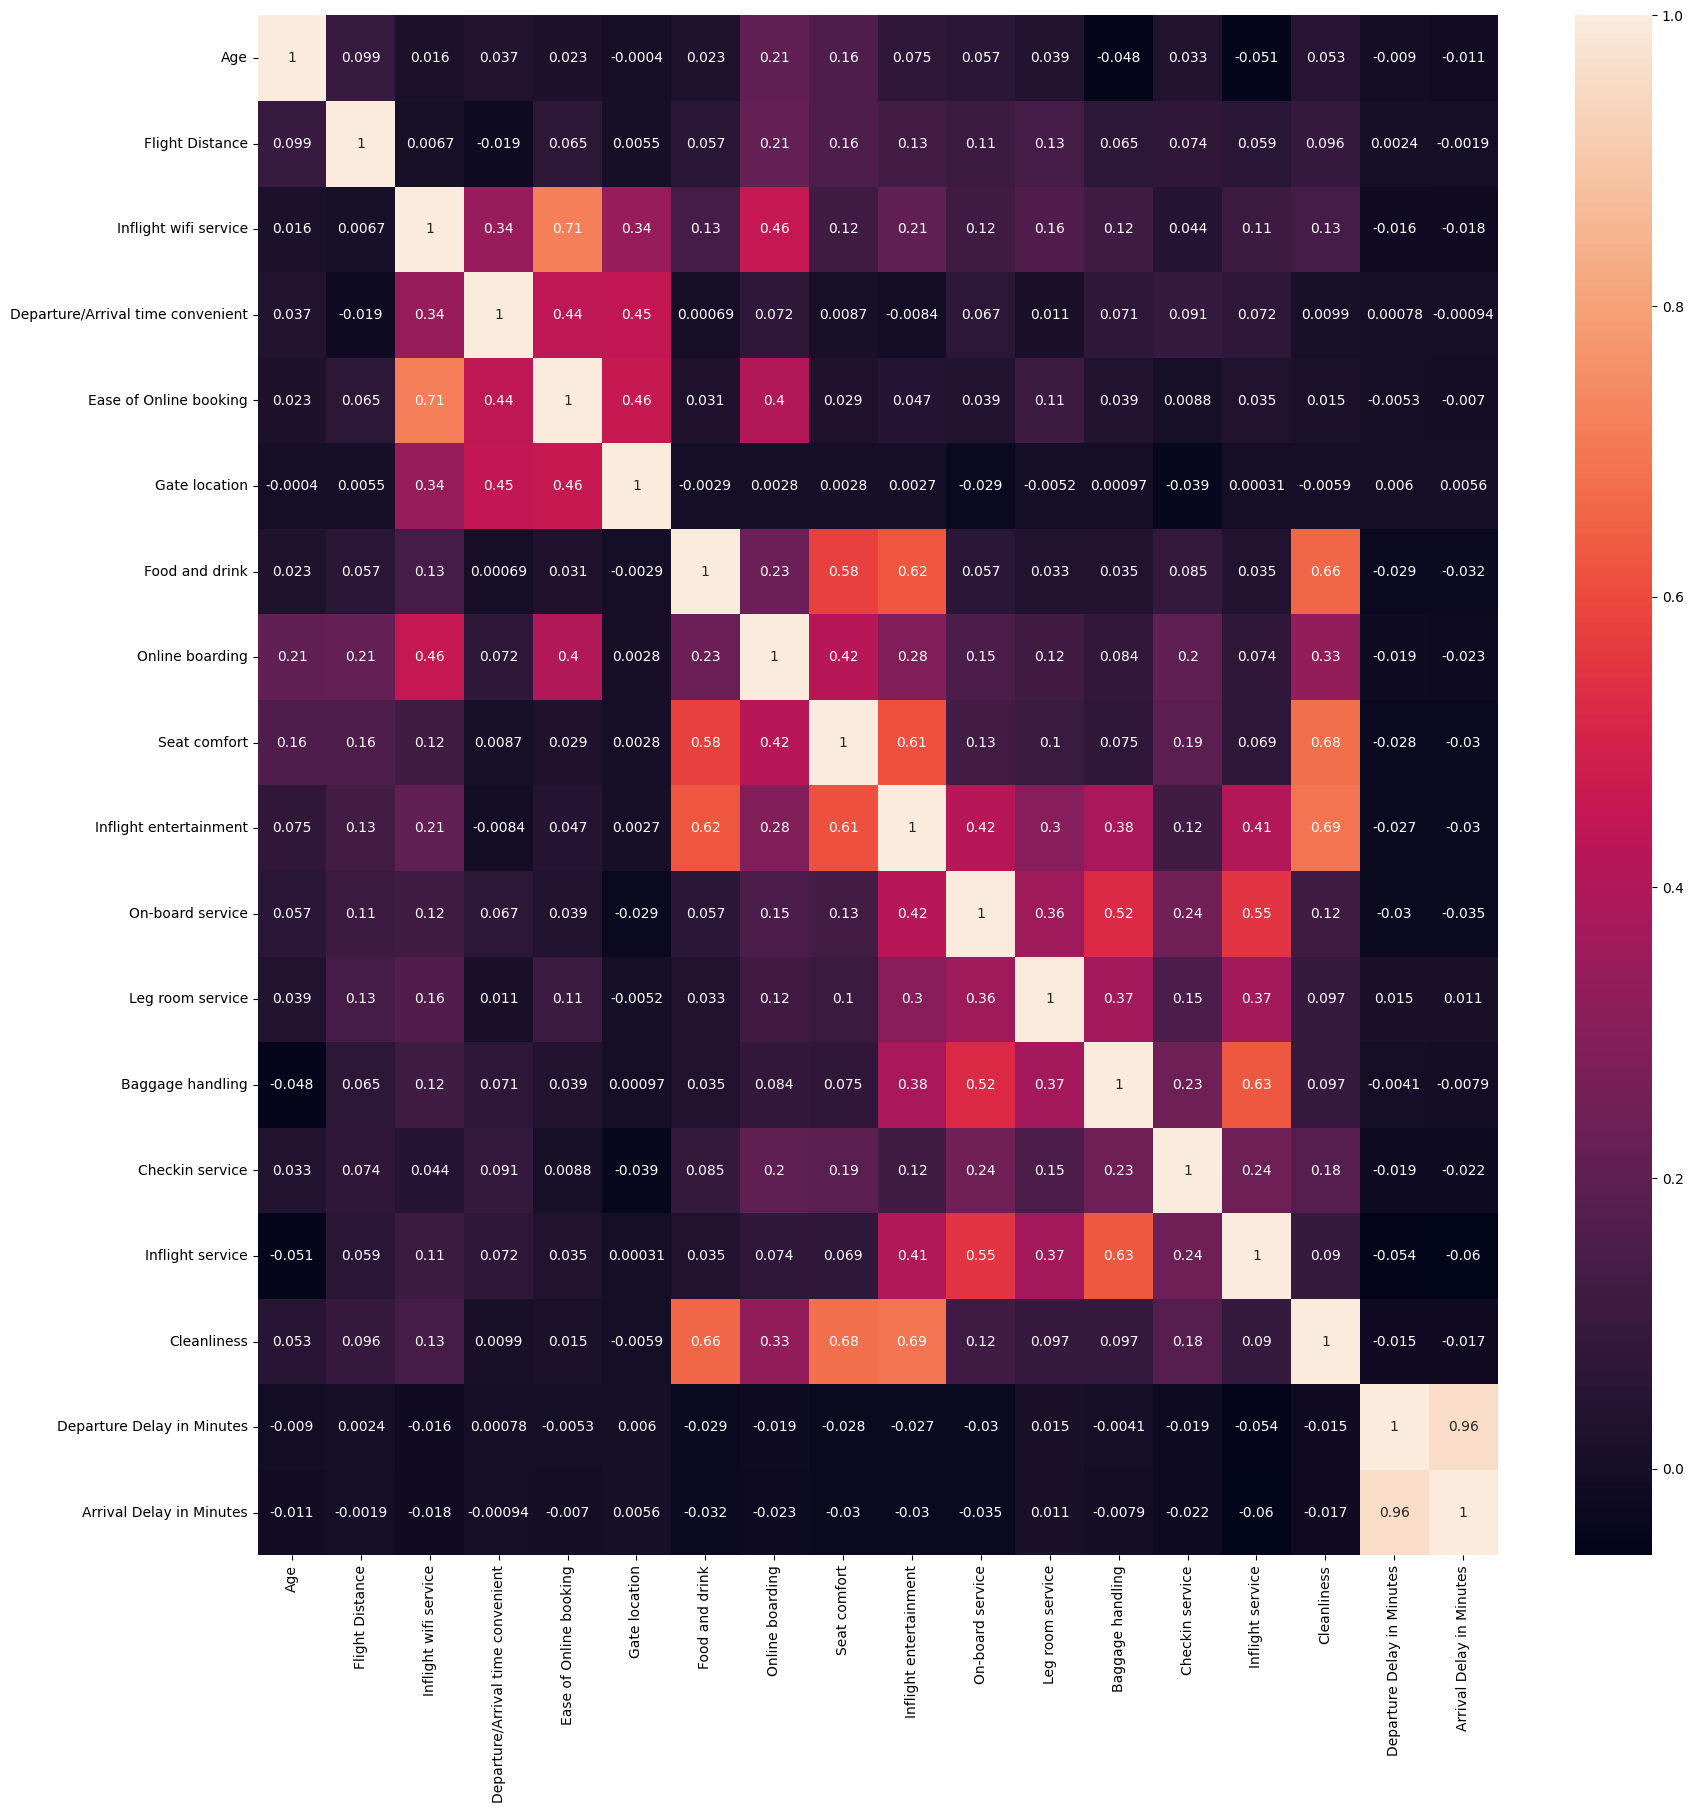

In [ ]:
f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True)

## Outlier Handling:

In [ ]:
def replace_higher_outliers(df, col):
    Q3 = df[col].quantile(0.75)
    IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
    upper_boundary = Q3 + (1.5 * IQR)

    df.loc[df[col] > upper_boundary, col] = upper_boundary

    return df



df = replace_higher_outliers(df, 'Flight Distance')
df = replace_higher_outliers(df, 'Departure Delay in Minutes')
df = replace_higher_outliers(df, 'Arrival Delay in Minutes')

## Mapping Satisfaction Levels to Numerical Values


In [ ]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

## Split the Independent and Dependent variables

In [ ]:
X = df.drop("satisfaction", axis = 1)

In [ ]:
X

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,5,25,18.0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,4,1,1,6.0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,4,5,0,0.0
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,4,2,11,9.0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,...,4,4,3,2,4,4,5,4,0,0.0
129876,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,...,4,4,4,5,5,5,5,4,0,0.0
129877,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,...,2,2,4,3,4,5,4,2,0,0.0
129878,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,...,4,4,3,2,5,4,5,4,0,0.0


In [ ]:
y = df["satisfaction"]

## One Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
oh = OneHotEncoder()

In [ ]:
ct = ColumnTransformer(transformers = [("ohe", oh,["Gender","Customer Type","Type of Travel","Class"])], remainder = "passthrough")

In [ ]:
X = ct.fit_transform(X)

In [ ]:
X

array([[ 0.,  1.,  1., ...,  5., 25., 18.],
       [ 0.,  1.,  0., ...,  1.,  1.,  6.],
       [ 1.,  0.,  1., ...,  5.,  0.,  0.],
       ...,
       [ 1.,  0.,  1., ...,  2.,  0.,  0.],
       [ 0.,  1.,  1., ...,  4.,  0.,  0.],
       [ 1.,  0.,  1., ...,  1.,  0.,  0.]])

In [ ]:
X.shape

(129880, 27)

In [ ]:
type(X)

numpy.ndarray

In [ ]:

y.shape

(129880,)

In [ ]:
y.value_counts(normalize=True)

satisfaction
0    0.565537
1    0.434463
Name: proportion, dtype: float64

## Split the data into train and test set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state = 42)

In [ ]:
X_train

array([[ 1. ,  0. ,  1. , ...,  5. , 11. ,  4. ],
       [ 0. ,  1. ,  0. , ...,  3. , 30. , 32.5],
       [ 1. ,  0. ,  1. , ...,  4. ,  0. ,  0. ],
       ...,
       [ 1. ,  0. ,  1. , ...,  5. ,  0. ,  0. ],
       [ 1. ,  0. ,  1. , ...,  4. ,  0. ,  0. ],
       [ 0. ,  1. ,  1. , ...,  2. ,  0. ,  0. ]])

In [ ]:
X_train.shape

(103904, 27)

In [ ]:
X_test.shape

(25976, 27)

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()#Creatin the object

In [ ]:
#fit -- To apply the formula
#transform --
X_train = sc.fit_transform(X_train)

In [ ]:
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[ 0.98623577, -0.98623577,  0.47483775, ...,  1.3056862 ,
         0.32115037, -0.33064968],
       [-1.01395633,  1.01395633, -2.10598253, ..., -0.21881382,
         2.01388144,  2.04857524],
       [ 0.98623577, -0.98623577,  0.47483775, ...,  0.54343619,
        -0.65885183, -0.66457598],
       ...,
       [ 0.98623577, -0.98623577,  0.47483775, ...,  1.3056862 ,
        -0.65885183, -0.66457598],
       [ 0.98623577, -0.98623577,  0.47483775, ...,  0.54343619,
        -0.65885183, -0.66457598],
       [-1.01395633,  1.01395633,  0.47483775, ..., -0.98106383,
        -0.65885183, -0.66457598]])

In [ ]:
X_test

array([[-1.01395633,  1.01395633,  0.47483775, ...,  0.54343619,
        -0.65885183, -0.66457598],
       [ 0.98623577, -0.98623577,  0.47483775, ...,  0.54343619,
        -0.39157851, -0.66457598],
       [ 0.98623577, -0.98623577,  0.47483775, ..., -0.98106383,
        -0.65885183, -0.66457598],
       ...,
       [-1.01395633,  1.01395633,  0.47483775, ...,  0.54343619,
        -0.48066962, -0.66457598],
       [-1.01395633,  1.01395633,  0.47483775, ...,  1.3056862 ,
         2.01388144,  2.04857524],
       [ 0.98623577, -0.98623577,  0.47483775, ..., -0.21881382,
         0.14296815, -0.66457598]])

In [ ]:
y_train

21413     0
7284      0
86080     0
59842     1
69486     0
         ..
128106    1
103694    0
860       1
15795     0
121958    0
Name: satisfaction, Length: 103904, dtype: int64

## Build the Neural network model
## Build the Architechture

In [ ]:
pip install tensorflow

In [ ]:
###### Import the libraries ##########
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense #Computations
from tensorflow.keras.layers import Input

In [ ]:
#Instance of NN model
nn_model = Sequential()

In [ ]:
X_train.shape[1]

27

## Add Input layers

In [ ]:
#shape of the input -- no of neurons in input layer

inp_layer = Input(shape = (X_train.shape[1],) )

In [ ]:
nn_model.add(inp_layer)

## Add Hidden layers

In [ ]:
#units -- no of neurons in particular layer
#kernel -- weights kernel_initializer - weights -- init strategy -- random_uniform
#activation -- the activation function to be used in this layer
hidden_layer = Dense(units = 512, kernel_initializer = "random_uniform",bias_initializer = "random_uniform", activation = "relu")

In [ ]:
nn_model.add(hidden_layer)

In [ ]:
hidden_layer_2 = Dense(units = 256, kernel_initializer = "random_uniform",bias_initializer = "random_uniform", activation = "relu")

In [ ]:
nn_model.add(hidden_layer_2)

In [ ]:
hidden_layer_3= Dense(units = 128, kernel_initializer = "random_uniform",bias_initializer = "random_uniform", activation = "relu")

In [ ]:
nn_model.add(hidden_layer_3)

## Add output layer

In [ ]:
#units -- no of neurons in particular layer
#kernel -- weights kernel_initializer - weights -- init strategy -- random_uniform
#activation -- the activation function to be used in this layer

output_layer = Dense(units = 1, kernel_initializer = "random_uniform",
                             bias_initializer = "random_uniform", activation = "sigmoid")

In [ ]:
nn_model.add(output_layer)

## Compile the model

In [ ]:
from tensorflow.keras.metrics import Recall

In [ ]:
recall_m = Recall()

In [ ]:
recall_m


In [ ]:
############# Adam Optimizer #################

from tensorflow.keras.optimizers import Adam

adam_optimizer = Adam(learning_rate = 0.01, beta_1=0.9,
                                            beta_2=0.98,
                                            epsilon=1e-07)

In [ ]:
# Compile
#mention the strategies to be followed during training process


#loss -- loss computing strategy
#optimizer -- weights updating strategy(formula)
#metrics -- to compute model performance at each epoch

nn_model.compile(loss = "binary_crossentropy", optimizer = adam_optimizer, metrics = [recall_m])

In [ ]:
nn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               14336     
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 178689 (698.00 KB)
Trainable params: 178689 (698.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
pip install pydot

In [ ]:
pip install graphviz

In [ ]:
from tensorflow.keras.utils import plot_model

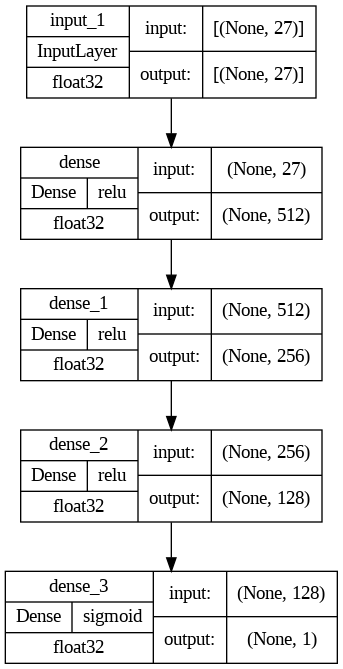

In [ ]:
plot_model(nn_model, show_shapes = True, show_dtype = True, show_layer_activations = True)

## Train the Model

In [ ]:
X_train.shape

(103904, 27)

In [ ]:
93513/32

2922.28125

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1,random_state = 42)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard

In [ ]:
ckpt = ModelCheckpoint("airlines_satisfaction.keras", monitor = "val_loss", verbose = 10,  save_best_only = True, mode = "min")

In [ ]:
tensor_board = TensorBoard(log_dir="logs",  write_images = True)

In [ ]:
tensor_board

In [ ]:
#epochs -- no of iteration
#batch_size -- no of observations to be used while updating the weights and batch processing

#history -- save the training information

#validation_data -- by mentioning this parmeter we will know how model is performing for new data at each epoch

history = nn_model.fit(X_train, y_train, batch_size = 32,
                       epochs = 200,
                       validation_data = (X_val, y_val),
                       callbacks = [ckpt, tensor_board] )

Epoch 1/200
2922/2923 [============================>.] - ETA: 0s - loss: 0.1735 - recall: 0.9037
Epoch 1: val_loss improved from inf to 0.13948, saving model to airlines_satisfaction.keras
2923/2923 [==============================] - 32s 11ms/step - loss: 0.1735 - recall: 0.9037 - val_loss: 0.1395 - val_recall: 0.9424
Epoch 2/200
2913/2923 [============================>.] - ETA: 0s - loss: 0.1315 - recall: 0.9200
Epoch 2: val_loss improved from 0.13948 to 0.12945, saving model to airlines_satisfaction.keras
2923/2923 [==============================] - 27s 9ms/step - loss: 0.1315 - recall: 0.9199 - val_loss: 0.1294 - val_recall: 0.9402
Epoch 3/200
2921/2923 [============================>.] - ETA: 0s - loss: 0.1219 - recall: 0.9245
Epoch 3: val_loss improved from 0.12945 to 0.11932, saving model to airlines_satisfaction.keras
2923/2923 [==============================] - 17s 6ms/step - loss: 0.1219 - recall: 0.9245 - val_loss: 0.1193 - val_recall: 0.9352
Epoch 4/200
2919/2923 [===========

In [ ]:
history.history

{'loss': [0.17352546751499176,
  0.131531223654747,
  0.1218748614192009,
  0.11922957003116608,
  0.11595223844051361,
  0.12319959700107574,
  0.11476040631532669,
  0.11424615979194641,
  0.11572987586259842,
  0.1109619066119194,
  0.11793731898069382,
  0.11864510923624039,
  0.12195397913455963,
  0.11977639049291611,
  0.11769329756498337,
  0.12621404230594635,
  0.12527021765708923,
  0.12873034179210663,
  0.12714546918869019,
  0.15379996597766876,
  0.1394861936569214,
  0.13497044146060944,
  0.1373920738697052,
  0.14495068788528442,
  0.14142785966396332,
  0.14018934965133667,
  0.15012557804584503,
  0.15265291929244995,
  0.15537691116333008,
  0.16373443603515625,
  0.15730448067188263,
  0.17234748601913452,
  0.16084271669387817,
  0.1695495843887329,
  0.18420004844665527,
  0.17661379277706146,
  0.1901424080133438,
  0.1951586753129959,
  0.2151305377483368,
  0.19426041841506958,
  0.22621189057826996,
  0.23435638844966888,
  0.20885750651359558,
  0.186968013

In [ ]:
len(history.history["loss"])

200

In [ ]:
train_loss = history.history["loss"]

In [ ]:
epochs = list(range(1,len(train_loss)+1))

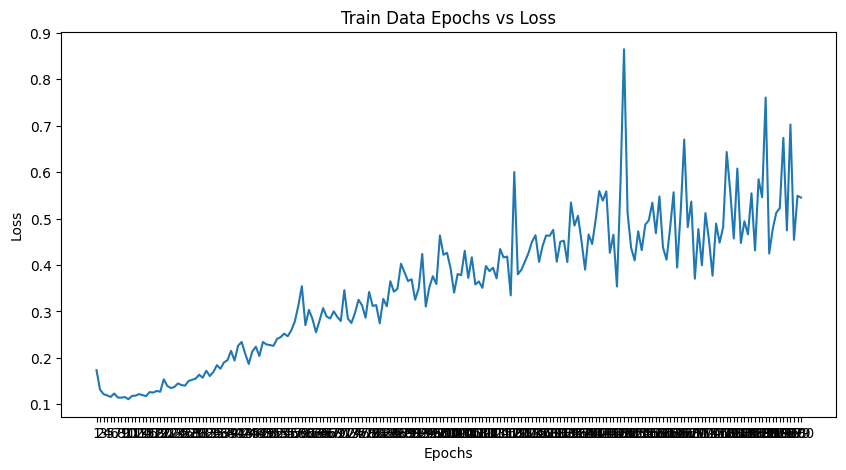

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(epochs, train_loss)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train Data Epochs vs Loss")
plt.show()

In [ ]:
accuracy_scores = history.history["recall"]

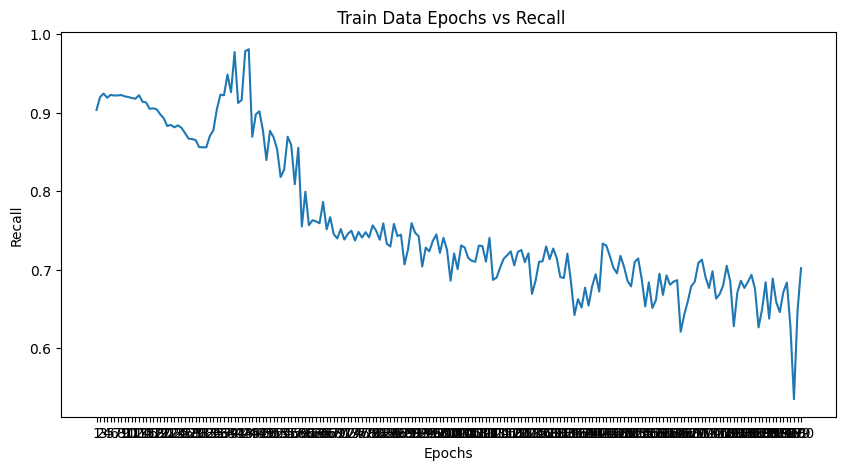

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(epochs, accuracy_scores)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title(" Train Data Epochs vs Recall")
plt.show()

In [ ]:
val_loss = history.history["val_loss"]

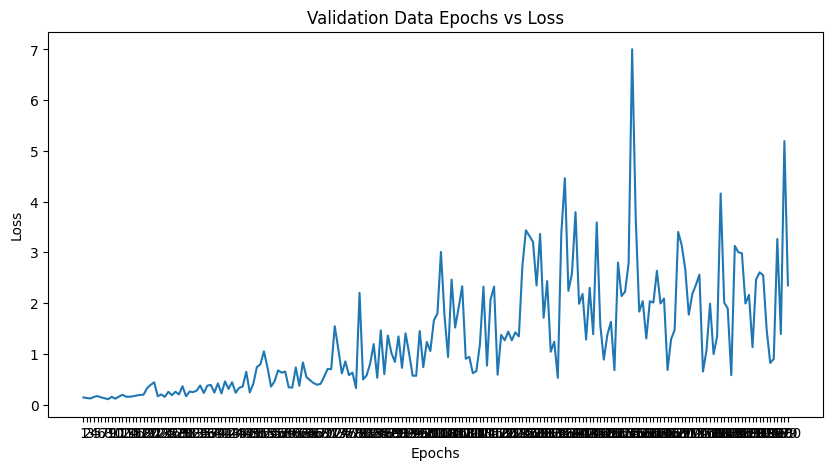

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(epochs, val_loss)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Data Epochs vs Loss")
plt.show()

In [ ]:
val_recall = history.history["val_recall"]

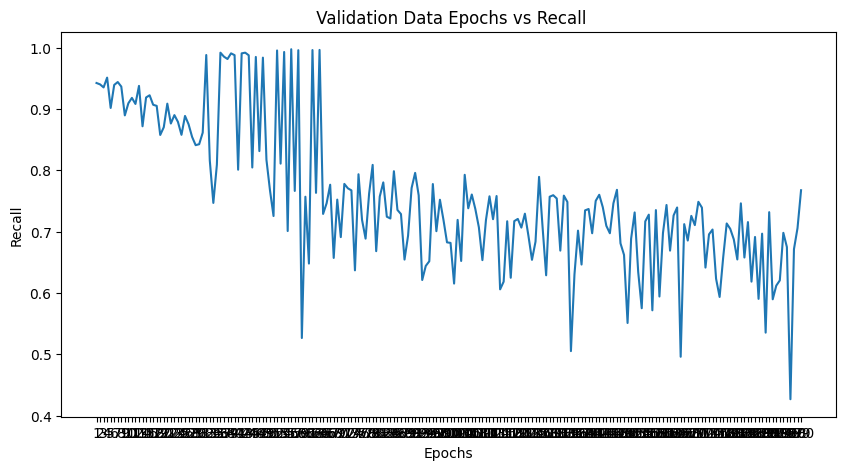

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(epochs, val_recall)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title(" Validation Data Epochs vs Recall")
plt.show()

## Evaluate the Model

In [ ]:
X_test.shape

(25976, 27)

In [ ]:
25976 / 32

811.75

In [ ]:
y_pred = nn_model.predict(X_test)

812/812 [==============================] - 3s 4ms/step


In [ ]:
y_pred

array([[0.        ],
       [0.30015582],
       [0.30015582],
       ...,
       [0.30015582],
       [1.        ],
       [0.        ]], dtype=float32)

In [ ]:
y_pred = y_pred > 0.7

In [ ]:
y_pred = y_pred.astype("int")

In [ ]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [1],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
print("Test Accuracy score :", accuracy_score(y_test, y_pred))

Test Accuracy score : 0.8927471512165075


In [ ]:
from mlxtend.plotting import plot_confusion_matrix

In [ ]:
cm_test = confusion_matrix(y_test, y_pred)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

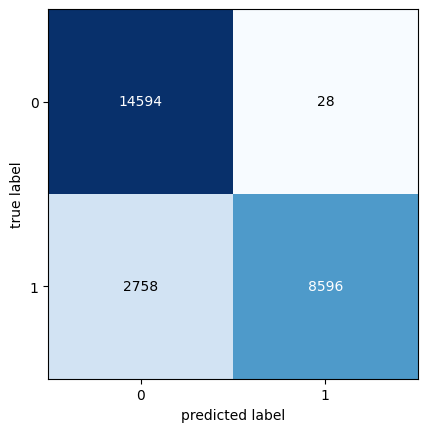

In [ ]:
plot_confusion_matrix(cm_test)

In [ ]:
cm_test

array([[14594,    28],
       [ 2758,  8596]])

In [ ]:
pip install mlxtend

## Real-time prediction

In [ ]:
def preprocess_input(data):
    data = pd.DataFrame([data])
    data = ct.transform(data)
    data = sc.transform(data)
    return data

def predict_satisfaction(model, data):
    processed_data = preprocess_input(data)
    prediction = model.predict(processed_data)
    return "satisfied" if prediction > 0.7 else "neutral or dissatisfied"


In [ ]:
new_data = {
 "Gender": "Male",
    "Customer Type": "Loyal Customer",
    "Age": 35,
    "Type of Travel": "Business travel",
    "Class": "Business",
    "Flight Distance": 500,
    "Departure Delay in Minutes": 0,
    "Arrival Delay in Minutes": 0,
    "Ease of Online booking": 3,
    "Gate location": 3,
    "Food and drink": 3,
    "Online boarding": 3,
    "Seat comfort": 3,
    "Inflight entertainment": 3,
    "On-board service": 3,
    "Leg room service": 3,
    "Baggage handling": 3,
    "Checkin service": 3,
    "Inflight service": 3,
    "Cleanliness": 3,
    "Departure/Arrival time convenient": 3,
    "Inflight wifi service": 3,
}

print(predict_satisfaction(nn_model, new_data))

1/1 [==============================] - 0s 41ms/step
neutral or dissatisfied


## Save the model

In [ ]:
nn_model.save("airlines_satisfaction.keras")

In [ ]:
import joblib

In [ ]:
joblib.dump(sc, "airlines_sc.pkl")

['airlines_sc.pkl']

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

In [ ]:
# Logistic Regression
log_reg = LogisticRegression()
param_grid_lr = {'C': [0.1, 1]}
grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=2)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
param_grid_dt = {'max_depth': [5, 10], 'min_samples_split': [10, 20]}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=2)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
param_grid_rf = {'n_estimators': [50], 'max_depth': [10, 15]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=2)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Support Vector Machine
svm = SVC(probability=True)
param_grid_svm = {'C': [0.1, 1], 'kernel': ['linear']}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=2)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

In [ ]:
# Performance Metrics
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, recall, precision, f1

models = {'Logistic Regression': y_pred_lr, 'Decision Tree': y_pred_dt,
          'Random Forest': y_pred_rf, 'SVM': y_pred_svm, 'ANN': y_pred}

results = {}
for model_name, y_pred in models.items():
    results[model_name] = evaluate_model(y_test, y_pred)

results_df = pd.DataFrame(results, index=['Accuracy', 'Recall', 'Precision', 'F1 Score'])

In [ ]:
results_df

,Logistic Regression,Decision Tree,Random Forest,SVM,ANN
Accuracy,0.874923,0.945642,0.959809,0.877271,0.892747
Recall,0.838119,0.916769,0.940638,0.833010,0.757090
Precision,0.870870,0.957061,0.966516,0.879814,0.996753
F1 Score,0.854181,0.936482,0.953401,0.855773,0.860547


In [ ]:
results_df

,Logistic Regression,Decision Tree,Random Forest,SVM,ANN
Accuracy,0.874923,0.945642,0.959809,0.877271,0.892747
Recall,0.838119,0.916769,0.940638,0.833010,0.757090
Precision,0.870870,0.957061,0.966516,0.879814,0.996753
F1 Score,0.854181,0.936482,0.953401,0.855773,0.860547
